# Desktop parameter search — round 4 (best cps + cpr together, threshold locked)

Question: with `holiday_threshold` locked at its center (−0.032), what's the best the two trend
levers `cps` and `cpr` can do **together**? Rounds 2–3 showed each peaks near cps≈0.09 / cpr≈0.55
(~+12k each) but the one combo tested (0.10983+0.60) came in *below* either alone (+3.7k) — a
negative interaction. This maps a cps×cpr grid around the peaks (same re-anchored data, 2026-07-06).

Outputs: `cps_cpr_grid.csv` + `plots/desktop_gradient_round4/{cps_cpr_heatmap,best_cps_cpr}.png`.


In [1]:
# [gr4-setup]
import os
import glob
import json
import sys
import time
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from google.cloud import bigquery

os.chdir(subprocess.run(["git", "rev-parse", "--show-toplevel"],
                        capture_output=True, text=True).stdout.strip())

# cps×cpr grid (round4) + single-knob peaks & center (rounds 2/3), threshold locked at center.
ROUND_DIRS = [
    "research/param-scans/results/desktop_gradient_round2",
    "research/param-scans/results/desktop_gradient_round3",
    "research/param-scans/results/desktop_gradient_round4",
]
OUT_DIR = "research/param-scans/results/desktop_gradient_round4"
PLOTS_DIR = "research/param-scans/plots/desktop_gradient_round4"
ADJUSTMENTS_DIR = "data-official/2026-07/adjustments"
os.makedirs(PLOTS_DIR, exist_ok=True)

FORECAST_START = pd.Timestamp("2026-07-06")
FORECAST_START_STR = "2026-07-06"
DISPLAY_START = pd.Timestamp("2026-01-01")
DISPLAY_END = pd.Timestamp("2026-12-31")
MEASUREMENT_DATE = pd.Timestamp("2026-12-15")
BQ_START = "2025-12-04"

HEADWIND_DEC15 = -1_370_000
CENTER_KPI_PRE = 49_890_449
CURRENT_FINAL = 48_520_449
TARGET_FINAL = 48_584_362

DEFAULTS = {
    "prophet_changepoint_prior_scale": 0.15983, "prophet_recent_weeks": 13,
    "prophet_changepoint_range": 0.7, "prophet_n_changepoints": 25,
    "holiday_threshold": -0.032, "holiday_max_radius": 5,
    "holiday_min_radius": 3, "holiday_effect_floor": -0.6,
}
CPS_FIELD = "prophet_changepoint_prior_scale"
CPR_FIELD = "prophet_changepoint_range"

print(f"center final = {CURRENT_FINAL:,}   target = {TARGET_FINAL:,}   gap = {TARGET_FINAL - CURRENT_FINAL:+,}")
print("Single-knob peaks (threshold at center): cps=0.08983 → +12,102 ; cpr=0.55 → +12,572")


center final = 48,520,449   target = 48,584,362   gap = +63,913
Single-knob peaks (threshold at center): cps=0.08983 → +12,102 ; cpr=0.55 → +12,572


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


In [2]:
# [gr3-helpers]
sys.path.insert(0, "data-official/2026-06")
from export_canonical_curves import display_ma  # noqa: E402

SEG_ALL = '{"os": "ALL"}'


def daily_to_28ma(dates, values):
    s = pd.Series(np.asarray(values, dtype=float), index=pd.to_datetime(np.asarray(dates)))
    return s.sort_index().rolling(28).mean()


def render_adjustment(spec, date_index):
    idx = pd.DatetimeIndex(date_index)
    desktop = pd.Series(0.0, index=idx)
    if spec["type"] == "linear_ramp":
        start = pd.Timestamp(spec["start_date"])
        anchor = pd.Timestamp(spec["anchor_date"])
        total_days = (anchor - start).days
        elapsed = np.maximum(0, (idx - start).days)
        desktop[:] = spec.get("desktop_dau", 0) * elapsed / total_days
    elif spec["type"] == "step":
        start = pd.Timestamp(spec["start_date"])
        end = pd.Timestamp(spec["end_date"]) if "end_date" in spec else idx[-1]
        desktop[(idx >= start) & (idx <= end)] = spec.get("desktop_dau", 0)
    return desktop


def load_desktop_adjustment(date_index):
    idx = pd.DatetimeIndex(date_index)
    total = pd.Series(0.0, index=idx)
    for path in sorted(glob.glob(f"{ADJUSTMENTS_DIR}/*.json")):
        with open(path) as f:
            total += render_adjustment(json.load(f), idx)
    return total


def all_labels():
    seen = set()
    for d in ROUND_DIRS:
        for x in os.listdir(d):
            if os.path.isdir(f"{d}/{x}"):
                seen.add(x)
    return sorted(seen)


def find_probe_parquet(label):
    for d in ROUND_DIRS:
        hits = glob.glob(f"{d}/{label}/*/mozaic_daily_forecast.{FORECAST_START_STR}.ld-D.adj-lo.parquet")
        if hits:
            return hits[0]
    return None


def probe_config(label):
    for d in ROUND_DIRS:
        pj = glob.glob(f"{d}/{label}/*/parameters.json")
        if pj:
            return json.load(open(pj[0]))["config"]
    return None


def nondefault(cfg):
    return {k: v for k, v in cfg.items() if abs(v - DEFAULTS[k]) > 1e-9}


def all_desktop_daily(parquet_path):
    df = pd.read_parquet(parquet_path)
    df["target_date"] = pd.to_datetime(df["target_date"])
    m = df[(df.data_source == "legacy_desktop") & (df.country == "ALL")
           & (df.app_name == "desktop") & (df.segment == SEG_ALL)]
    return m.sort_values("target_date")[["target_date", "dau"]].reset_index(drop=True)


def dec15_pre_headwind(parquet_path):
    d = all_desktop_daily(parquet_path)
    s = d.set_index("target_date")["dau"].astype(float)
    return float(s.rolling(28, min_periods=28).mean().loc[MEASUREMENT_DATE])


def forecast_ma_final(parquet_path):
    d = all_desktop_daily(parquet_path)
    ma = display_ma(d["target_date"], d["dau"], FORECAST_START)
    adj = load_desktop_adjustment(ma.index)
    out = ma.copy()
    fmask = out.index >= FORECAST_START
    out[fmask] = out[fmask] + adj[fmask]
    return out


In [3]:
# [gr2-actuals]
client = bigquery.Client(project="moz-fx-data-bq-data-science")
sql = f"""
    SELECT submission_date AS date, SUM(dau) AS dau
    FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
    WHERE app_name = "Firefox Desktop"
      AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE("America/Los_Angeles") - 2
    GROUP BY submission_date ORDER BY 1
"""
t0 = time.time()
sys.stdout.write("querying desktop actuals...")
sys.stdout.flush()
desktop_actuals = client.query(sql).to_dataframe()
desktop_actuals["date"] = pd.to_datetime(desktop_actuals["date"])
desktop_actual_ma = daily_to_28ma(desktop_actuals["date"], desktop_actuals["dau"])
sys.stdout.write(f" {len(desktop_actuals)} rows ({time.time() - t0:.1f}s); "
                 f"latest {desktop_actuals['date'].max().date()}\n")


querying desktop actuals...

 214 rows (8.7s); latest 2026-07-05


36

In [4]:
# [gr4-grid-table]
center_pre = dec15_pre_headwind(find_probe_parquet("center"))
assert abs(center_pre - CENTER_KPI_PRE) < 1

# Collect all cps×cpr combos (exactly the two knobs changed, both present).
grid_rows = []
for lab in all_labels():
    if not lab.startswith("combo__"):
        continue
    nd = nondefault(probe_config(lab))
    if set(nd) != {CPS_FIELD, CPR_FIELD}:
        continue
    pq = find_probe_parquet(lab)
    pre = dec15_pre_headwind(pq)
    grid_rows.append({
        "cps": round(nd[CPS_FIELD], 5), "cpr": round(nd[CPR_FIELD], 3),
        "final": pre + HEADWIND_DEC15, "vs_center": pre - center_pre,
        "vs_target": (pre + HEADWIND_DEC15) - TARGET_FINAL,
    })
grid = pd.DataFrame(grid_rows).sort_values("vs_center", ascending=False).reset_index(drop=True)
grid.to_csv(f"{OUT_DIR}/cps_cpr_grid.csv", index=False)

# Reference points.
cps_peak = dec15_pre_headwind(find_probe_parquet("cps__0.08983")) - center_pre
cpr_peak = dec15_pre_headwind(find_probe_parquet("cpr__0.55")) - center_pre
best = grid.iloc[0]

print(f"Single-knob best (threshold@center):  cps=0.08983 → {cps_peak:+,.0f}   "
      f"cpr=0.55 → {cpr_peak:+,.0f}   (max single = {max(cps_peak, cpr_peak):+,.0f})")
print(f"BEST cps×cpr combo: cps={best['cps']:g}, cpr={best['cpr']:g} → "
      f"{best['final']:,.0f}  ({best['vs_center']:+,.0f} vs center, {best['vs_target']:+,.0f} vs target)")
verdict = ("BEATS" if best['vs_center'] > max(cps_peak, cpr_peak) else "does NOT beat")
print(f"=> best joint combo {verdict} the best single knob "
      f"(by {best['vs_center'] - max(cps_peak, cpr_peak):+,.0f}).\n")

show = grid.copy()
show["final"] = show["final"].map(lambda v: f"{v:,.0f}")
for c in ["vs_center", "vs_target"]:
    show[c] = show[c].map(lambda v: f"{v:+,.0f}")
print(show.to_string(index=False))
grid


Single-knob best (threshold@center):  cps=0.08983 → +12,102   cpr=0.55 → +12,572   (max single = +12,572)
BEST cps×cpr combo: cps=0.07, cpr=0.65 → 48,567,438  (+46,989 vs center, -16,924 vs target)
=> best joint combo BEATS the best single knob (by +34,418).

    cps  cpr      final vs_center vs_target
0.07000 0.65 48,567,438   +46,989   -16,924
0.08983 0.65 48,560,483   +40,034   -23,879
0.10983 0.55 48,550,862   +30,413   -33,500
0.12983 0.65 48,533,889   +13,440   -50,473
0.10983 0.65 48,531,972   +11,523   -52,390
0.10983 0.60 48,524,191    +3,742   -60,171
0.12983 0.55 48,521,596    +1,147   -62,766
0.08983 0.55 48,521,230      +781   -63,132
0.13983 0.55 48,514,984    -5,465   -69,378
0.08983 0.60 48,513,531    -6,918   -70,831
0.12983 0.60 48,512,020    -8,429   -72,342
0.05000 0.45 48,364,194  -156,255  -220,168
0.03000 0.40 47,738,781  -781,668  -845,581


,cps,cpr,final,vs_center,vs_target
0,0.07000,0.65,4.856744e+07,46989.483524,-16923.512368
1,0.08983,0.65,4.856048e+07,40034.312689,-23878.683203
2,0.10983,0.55,4.855086e+07,30412.603321,-33500.392571
3,0.12983,0.65,4.853389e+07,13440.166973,-50472.828919
4,0.10983,0.65,4.853197e+07,11522.527674,-52390.468218
5,0.10983,0.60,4.852419e+07,3741.906654,-60171.089238
6,0.12983,0.55,4.852160e+07,1146.991598,-62766.004294
7,0.08983,0.55,4.852123e+07,781.465841,-63131.530051
8,0.13983,0.55,4.851498e+07,-5465.149900,-69378.145792
9,0.08983,0.60,4.851353e+07,-6918.121425,-70831.117317


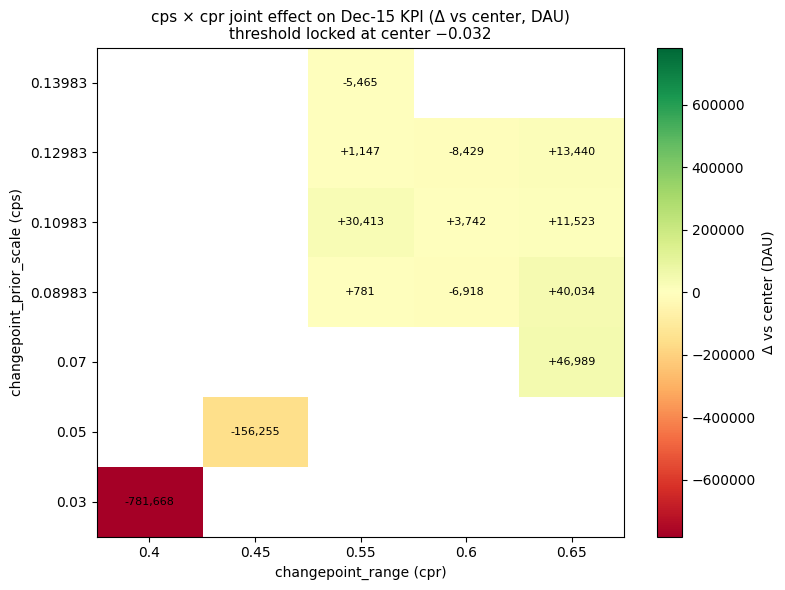

saved research/param-scans/plots/desktop_gradient_round4/cps_cpr_heatmap.png


In [5]:
# [gr4-heatmap]
# Response surface: Δ vs center (DAU) over the cps×cpr grid. Includes the center row/col as
# reference (cps=0.15983 or cpr=0.7 with the other varied = single-knob effects), when present.
pivot = grid.pivot(index="cps", columns="cpr", values="vs_center").sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
vmax = np.nanmax(np.abs(pivot.values))
im = ax.imshow(pivot.values, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{c:g}" for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"{r:g}" for r in pivot.index])
ax.set_xlabel("changepoint_range (cpr)")
ax.set_ylabel("changepoint_prior_scale (cps)")
ax.set_title("cps × cpr joint effect on Dec-15 KPI (Δ vs center, DAU)\n"
             "threshold locked at center −0.032", fontsize=11)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:+,.0f}", ha="center", va="center", fontsize=8,
                    color="black")
fig.colorbar(im, ax=ax, label="Δ vs center (DAU)")
plt.tight_layout()
out = f"{PLOTS_DIR}/cps_cpr_heatmap.png"
plt.savefig(out, dpi=130, bbox_inches="tight")
plt.show()
print(f"saved {out}")


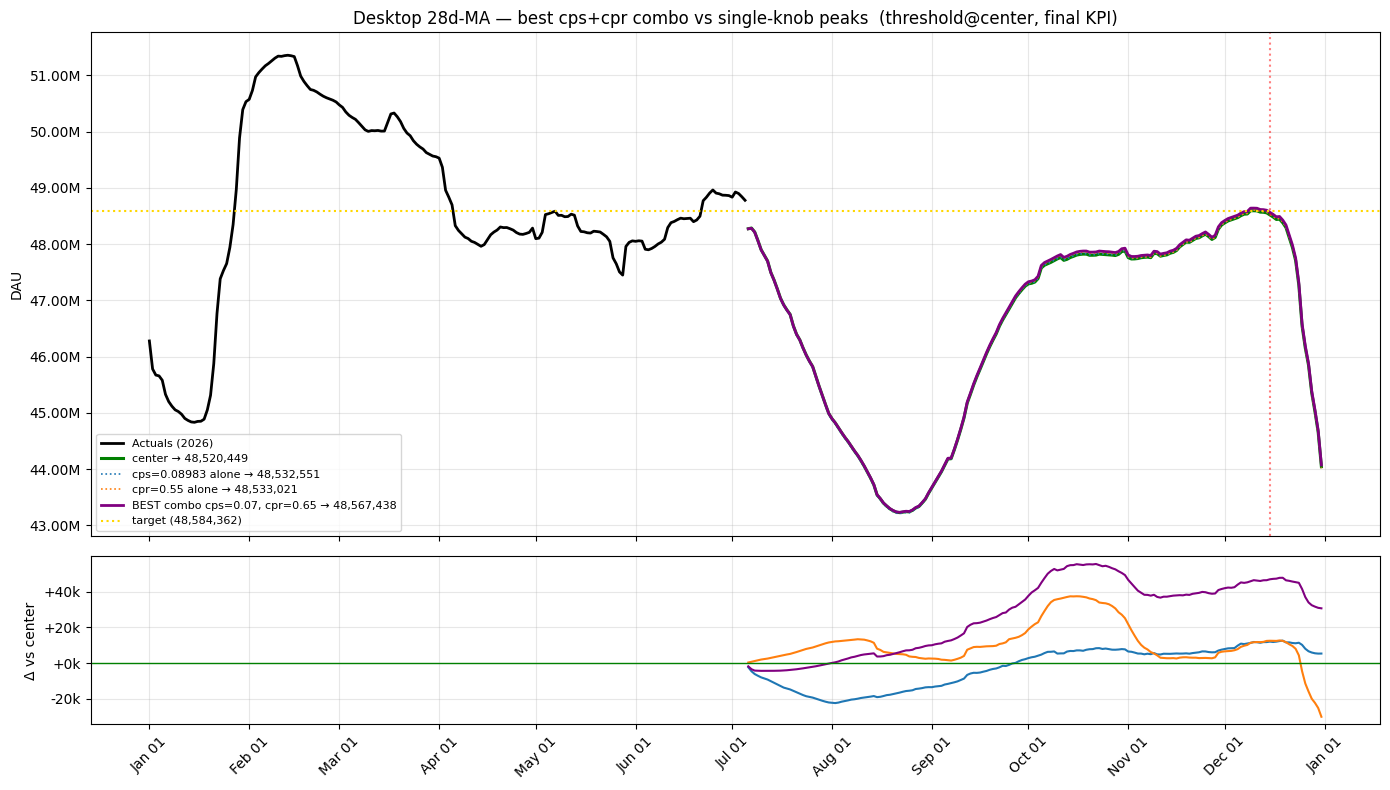

saved research/param-scans/plots/desktop_gradient_round4/best_cps_cpr.png


In [6]:
# [gr4-best-curve]
def clip_display(s):
    return s[(s.index >= DISPLAY_START) & (s.index <= DISPLAY_END)].dropna()


def clip_fc(s):
    return s[(s.index >= FORECAST_START) & (s.index <= DISPLAY_END)].dropna()


def mfmt(x, pos):
    return f"{x / 1e6:.2f}M"


center_ma = forecast_ma_final(find_probe_parquet("center"))
best = grid.iloc[0]


def find_combo_label(cps, cpr):
    for lab in all_labels():
        if not lab.startswith("combo__"):
            continue
        nd = nondefault(probe_config(lab))
        if set(nd) == {CPS_FIELD, CPR_FIELD} \
                and abs(nd[CPS_FIELD] - cps) < 1e-6 and abs(nd[CPR_FIELD] - cpr) < 1e-6:
            return lab
    raise ValueError(f"no combo probe for cps={cps}, cpr={cpr}")


best_lab = find_combo_label(best["cps"], best["cpr"])
best_ma = forecast_ma_final(find_probe_parquet(best_lab))
cps_ma = forecast_ma_final(find_probe_parquet("cps__0.08983"))
cpr_ma = forecast_ma_final(find_probe_parquet("cpr__0.55"))

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1]})
ax.plot(clip_display(desktop_actual_ma), color="black", lw=2, label="Actuals (2026)")
ax.plot(clip_fc(center_ma), color="green", lw=2.2,
        label=f"center → {center_ma.loc[MEASUREMENT_DATE]:,.0f}")
ax.plot(clip_fc(cps_ma), color="#1f77b4", lw=1.2, ls=":",
        label=f"cps=0.08983 alone → {cps_ma.loc[MEASUREMENT_DATE]:,.0f}")
ax.plot(clip_fc(cpr_ma), color="#ff7f0e", lw=1.2, ls=":",
        label=f"cpr=0.55 alone → {cpr_ma.loc[MEASUREMENT_DATE]:,.0f}")
ax.plot(clip_fc(best_ma), color="purple", lw=2,
        label=f"BEST combo cps={best['cps']:g}, cpr={best['cpr']:g} → {best_ma.loc[MEASUREMENT_DATE]:,.0f}")
ax.axhline(TARGET_FINAL, color="gold", ls=":", lw=1.5, label=f"target ({TARGET_FINAL:,})")
ax.axvline(MEASUREMENT_DATE, color="red", ls=":", alpha=0.5)
ax.set_title("Desktop 28d-MA — best cps+cpr combo vs single-knob peaks  "
             "(threshold@center, final KPI)", fontsize=12)
ax.set_ylabel("DAU")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(mfmt))
ax.legend(loc="lower left", fontsize=8)
ax.grid(True, alpha=0.3)
for ma, col in [(cps_ma, "#1f77b4"), (cpr_ma, "#ff7f0e"), (best_ma, "purple")]:
    d = clip_fc(ma - center_ma)
    ax2.plot(d.index, d.values, color=col)
ax2.axhline(0, color="green", lw=1)
ax2.set_ylabel("Δ vs center")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:+.0f}k"))
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout()
out = f"{PLOTS_DIR}/best_cps_cpr.png"
plt.savefig(out, dpi=130, bbox_inches="tight")
plt.show()
print(f"saved {out}")
